# Analyse Exploratoire des Transactions Financières

## Détection de schémas de fraude bancaire

**Auteur :** Silvéra ADODO

---

## Contexte

La fraude financière constitue un enjeu majeur pour les banques et les institutions financières. Une analyse exploratoire des données (EDA) permet de mieux comprendre les caractéristiques des transactions, de détecter des tendances et d'identifier des comportements potentiellement frauduleux avant la mise en place de modèles de détection.

---

## Objectif

Explorer un jeu de données de transactions financières afin d'identifier des schémas de fraude et proposer des recommandations basées sur les données.

---

## Problématique

**Comment analyser les transactions financières afin d'identifier des schémas de fraude ?**

In [44]:
# ======================================================
# Importation des bibliothèques
# ======================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Configuration des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [45]:
# ======================================================
# Chargement des données
# ======================================================

df = pd.read_csv(
    "../data/financial_fraud_detection_dataset.csv"
    #nrows=100000
)

In [46]:
# Afficher les 5 premières lignes
df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [47]:
# Nombre de lignes et de colonnes
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 5000000
Nombre de colonnes : 18


In [48]:
# Liste des colonnes
df.columns.tolist()

['transaction_id',
 'timestamp',
 'sender_account',
 'receiver_account',
 'amount',
 'transaction_type',
 'merchant_category',
 'location',
 'device_used',
 'is_fraud',
 'fraud_type',
 'time_since_last_transaction',
 'spending_deviation_score',
 'velocity_score',
 'geo_anomaly_score',
 'payment_channel',
 'ip_address',
 'device_hash']

In [49]:
# Informations sur le dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               str    
 1   timestamp                    str    
 2   sender_account               str    
 3   receiver_account             str    
 4   amount                       float64
 5   transaction_type             str    
 6   merchant_category            str    
 7   location                     str    
 8   device_used                  str    
 9   is_fraud                     bool   
 10  fraud_type                   str    
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              str    
 16  ip_address                   str    
 17  device_hash                  str    
dtypes: bool(1), float64(4), int64(1), str(12)
memory usag

In [50]:
# Statistiques des variables numériques
df.describe().T

,count,mean,std,min,25%,50%,75%,max
amount,5000000.0,358.934269,469.933311,0.010000,26.570000,138.670000,503.890000,3520.570000
time_since_last_transaction,4103487.0,1.525799,3576.568702,-8777.814182,-2562.376056,0.844275,2568.338671,8757.758483
spending_deviation_score,5000000.0,-0.000388,1.000807,-5.260000,-0.680000,0.000000,0.670000,5.020000
velocity_score,5000000.0,10.501320,5.766842,1.000000,5.000000,11.000000,16.000000,20.000000
geo_anomaly_score,5000000.0,0.500029,0.288635,0.000000,0.250000,0.500000,0.750000,1.000000


In [51]:
# Nombre de valeurs manquantes
df.isnull().sum()

transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64

In [52]:
# Pourcentage de valeurs manquantes
(df.isnull().sum() / len(df) * 100).round(2)

transaction_id                  0.00
timestamp                       0.00
sender_account                  0.00
receiver_account                0.00
amount                          0.00
transaction_type                0.00
merchant_category               0.00
location                        0.00
device_used                     0.00
is_fraud                        0.00
fraud_type                     96.41
time_since_last_transaction    17.93
spending_deviation_score        0.00
velocity_score                  0.00
geo_anomaly_score               0.00
payment_channel                 0.00
ip_address                      0.00
device_hash                     0.00
dtype: float64

In [53]:
# Nombre de doublons
df.duplicated().sum()

np.int64(0)

In [54]:
# Analyse des valeurs manquantes selon la fraude
pd.crosstab(
    df["is_fraud"],
    df["time_since_last_transaction"].isna(),
    margins=True
)

time_since_last_transaction,False,True,All
is_fraud,,,
False,3923934,896513,4820447
True,179553,0,179553
All,4103487,896513,5000000


In [55]:
# Conversion de la colonne timestamp
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="mixed"
)

In [56]:
# Ajout de colonnes pour l'année, le mois, le jour et l'heure
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour

In [57]:
# Vérification des nouvelles colonnes
df[["timestamp", "year", "month", "day", "hour"]].head()


,timestamp,year,month,day,hour
0,2023-08-22 09:22:43.516168,2023,8,22,9
1,2023-08-04 01:58:02.606711,2023,8,4,1
2,2023-05-12 11:39:33.742963,2023,5,12,11
3,2023-10-10 06:04:43.195112,2023,10,10,6
4,2023-09-24 08:09:02.700162,2023,9,24,8


In [58]:
# Nombre de transactions par classe
df["is_fraud"].value_counts()

is_fraud
False    4820447
True      179553
Name: count, dtype: int64

In [59]:
# Pourcentage de transactions
(df["is_fraud"].value_counts(normalize=True) * 100).round(2)

is_fraud
False    96.41
True      3.59
Name: proportion, dtype: float64

### Analyse de la variable cible (`is_fraud`)

Le jeu de données contient **5 000 000 transactions**, dont :

- **4 820 447 transactions légitimes (96,41 %)** ;
- **179 553 transactions frauduleuses (3,59 %)**.

Le dataset est donc **déséquilibré**, les transactions frauduleuses étant beaucoup moins nombreuses que les transactions légitimes.

Ce déséquilibre est fréquent dans les données de fraude bancaire et constitue un défi important pour la détection automatique des fraudes.

## 1. Analyse des montants des transactions

### Question métier

Les transactions frauduleuses présentent-elles des montants différents des transactions légitimes ?

Nous analysons la distribution des montants afin d'identifier d'éventuelles différences de comportement entre les deux groupes.

In [60]:
# Étape 1 — Statistiques par type de transaction
#  Statistiques descriptives des montants selon la fraude

df.groupby("is_fraud")["amount"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
False,4820447.0,358.95,469.95,0.01,26.57,138.71,503.96,3520.57
True,179553.0,358.53,469.53,0.01,26.48,137.88,501.72,3128.14


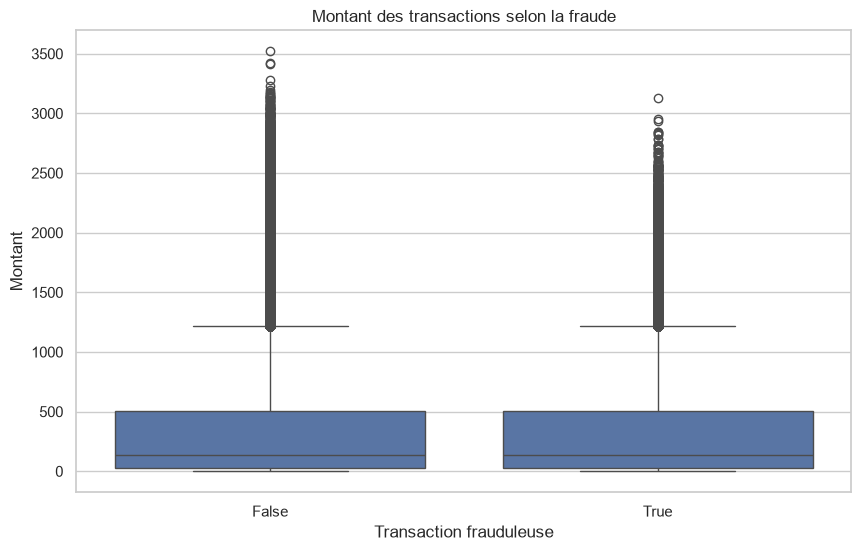

In [61]:
# Étape 2 — Boxplot -> Visualisation des montants selon la fraude
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount"
)

plt.title("Montant des transactions selon la fraude")
plt.xlabel("Transaction frauduleuse")
plt.ylabel("Montant")

plt.savefig("../images/amount_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

In [62]:
## Étape 3 — Histogramme -> Visualisation des montants selon la fraude
sample = df.sample(100000, random_state=42)

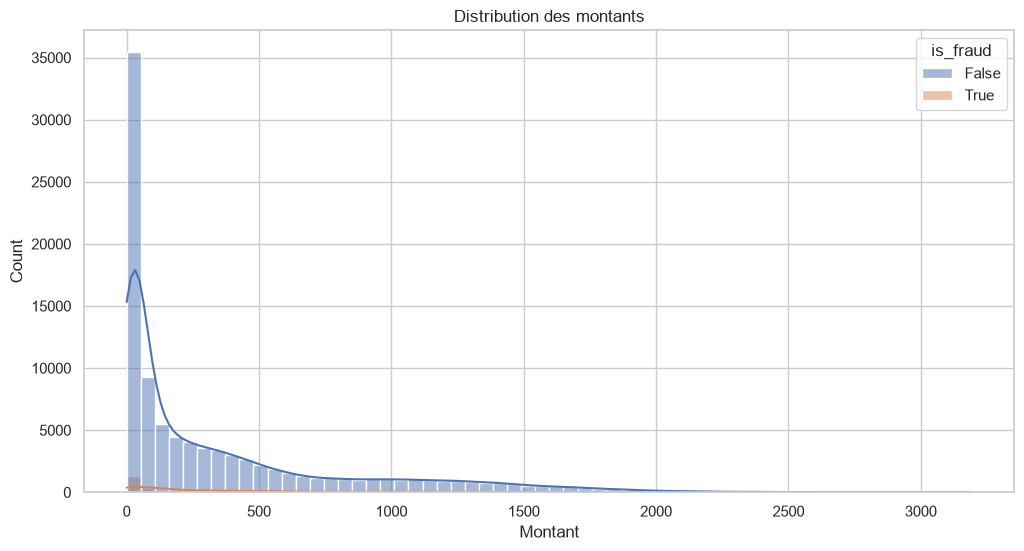

In [63]:
# Histogramme des montants
plt.figure(figsize=(12,6))

sns.histplot(
    data=sample,
    x="amount",
    hue="is_fraud",
    bins=60,
    kde=True
)

plt.title("Distribution des montants")
plt.xlabel("Montant")

plt.savefig("../images/amount_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

### Interprétation

Les statistiques descriptives ainsi que les visualisations montrent que les montants des transactions frauduleuses et des transactions légitimes sont très similaires.

La moyenne, la médiane et les quartiles présentent des valeurs proches pour les deux catégories de transactions.

Les montants des transactions ne semblent donc pas constituer un indicateur suffisant pour distinguer les transactions frauduleuses des transactions légitimes.

Cette observation suggère que la détection de fraude devra probablement s'appuyer davantage sur d'autres variables telles que le type de transaction, la localisation, le canal de paiement, le score de vélocité ou encore le score d'anomalie géographique.

## 2. Analyse du type de transaction

### Question métier

Certains types de transactions sont-ils davantage associés aux fraudes ?

Nous analysons la répartition des différents types de transactions afin d'identifier ceux qui présentent un risque plus élevé.

In [64]:
# Étape 1 : Répartition des types de transactions
df["transaction_type"].value_counts()

transaction_type
deposit       1250593
payment       1250438
transfer      1250334
withdrawal    1248635
Name: count, dtype: int64

In [65]:
# Étape 2 : Tableau croisé
pd.crosstab(
    df["transaction_type"],
    df["is_fraud"],
    margins=True
)


is_fraud,False,True,All
transaction_type,,,
deposit,1205807,44786,1250593
payment,1205873,44565,1250438
transfer,1205006,45328,1250334
withdrawal,1203761,44874,1248635
All,4820447,179553,5000000


In [66]:
# Étape 3 : Taux de fraude par type de transaction
fraud_rate = (
    df.groupby("transaction_type")["is_fraud"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

fraud_rate

transaction_type
transfer      3.63
withdrawal    3.59
deposit       3.58
payment       3.56
Name: is_fraud, dtype: float64

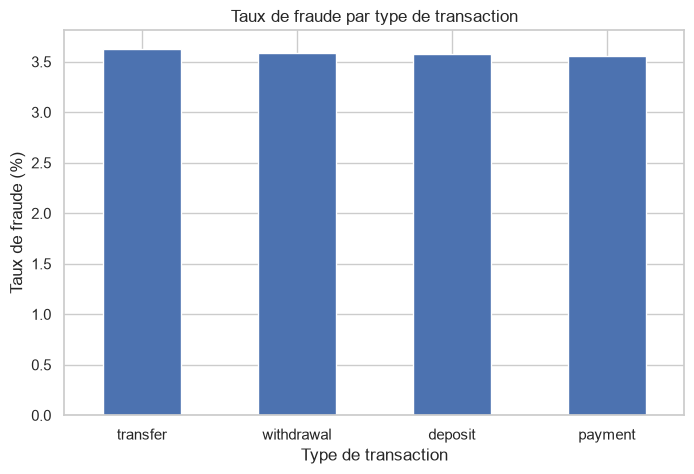

In [67]:
# Étape 4 - diagramme en barres
plt.figure(figsize=(8,5))

fraud_rate.plot(kind="bar")

plt.title("Taux de fraude par type de transaction")
plt.xlabel("Type de transaction")
plt.ylabel("Taux de fraude (%)")

plt.xticks(rotation=0)

plt.savefig("../images/fraud_by_transaction_type.png", dpi=300, bbox_inches="tight")

plt.show()

## 3. Analyse des catégories de commerçants

### Question métier

Certaines catégories de commerçants sont-elles davantage associées aux transactions frauduleuses ?

Cette analyse permet d'identifier les secteurs d'activité présentant un risque plus élevé afin d'aider les banques à renforcer leurs mécanismes de contrôle.

In [68]:
# Étape 1 : Répartition des catégories de commerçants
df["merchant_category"].value_counts()

merchant_category
retail           626319
travel           625656
restaurant       625483
entertainment    625332
grocery          624954
other            624589
utilities        624086
online           623581
Name: count, dtype: int64

In [69]:
# Étape 2 : Tableau croisé
pd.crosstab(
    df["merchant_category"],
    df["is_fraud"],
    margins=True
)

is_fraud,False,True,All
merchant_category,,,
entertainment,602759,22573,625332
grocery,602438,22516,624954
online,601257,22324,623581
other,602033,22556,624589
restaurant,603116,22367,625483
retail,603866,22453,626319
travel,603153,22503,625656
utilities,601825,22261,624086
All,4820447,179553,5000000


In [70]:
# Étape 3 : Calcul du taux de fraude
merchant_fraud_rate = (
    df.groupby("merchant_category")["is_fraud"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

merchant_fraud_rate

merchant_category
entertainment    3.61
other            3.61
grocery          3.60
travel           3.60
online           3.58
restaurant       3.58
retail           3.58
utilities        3.57
Name: is_fraud, dtype: float64

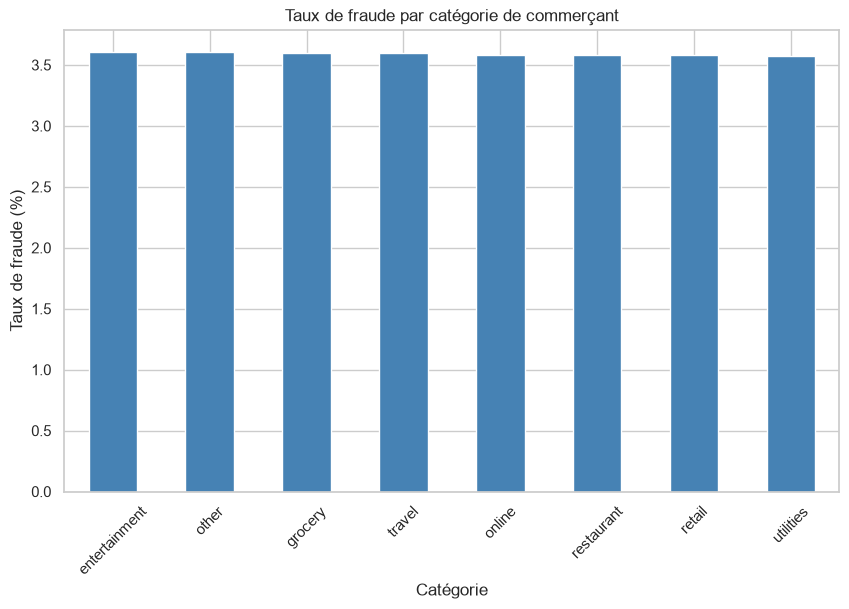

In [71]:
# Étape 4 : Diagramme en barres
plt.figure(figsize=(10,6))

merchant_fraud_rate.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Taux de fraude par catégorie de commerçant")
plt.xlabel("Catégorie")
plt.ylabel("Taux de fraude (%)")

plt.xticks(rotation=45)

plt.savefig("../images/fraud_by_merchant_category.png", dpi=300, bbox_inches="tight")

plt.show()

### Interprétation

Les différentes catégories de commerçants présentent des taux de fraude très proches, compris entre **3,57 % et 3,61 %**.

Aucune catégorie ne se démarque significativement des autres. Les activités telles que le commerce de détail, les voyages, la restauration ou les achats en ligne semblent exposées à un niveau de risque comparable.

Ainsi, la catégorie du commerçant ne constitue pas, à elle seule, un indicateur fiable permettant de distinguer les transactions frauduleuses des transactions légitimes.

Cette observation suggère que la détection de fraude devra s'appuyer sur des variables comportementales plus avancées.

## 4. Analyse du score de vélocité

### Question métier

Les transactions frauduleuses présentent-elles un score de vélocité plus élevé que les transactions légitimes ?

Le score de vélocité mesure l'intensité des transactions réalisées sur une courte période. Un score élevé peut traduire un comportement inhabituel ou potentiellement frauduleux.

In [72]:
# Étape 1 : Statistiques descriptives de la variable velocity_score selon la fraude
df.groupby("is_fraud")["velocity_score"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
False,4820447.0,10.50,5.77,1.0,5.0,11.0,16.0,20.0
True,179553.0,10.51,5.77,1.0,6.0,11.0,16.0,20.0


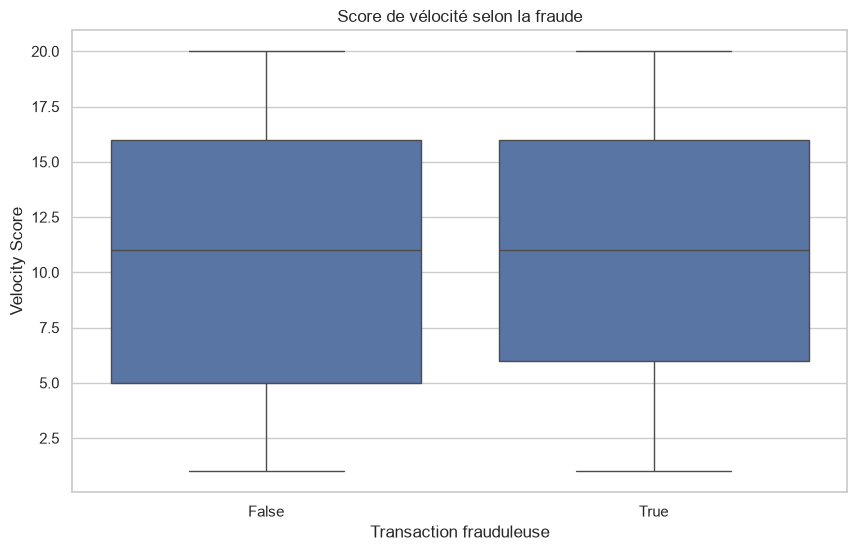

In [73]:
# Étape 2 : Boxplot -> Visualisation du score de vélocité selon la fraude
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="velocity_score"
)

plt.title("Score de vélocité selon la fraude")
plt.xlabel("Transaction frauduleuse")
plt.ylabel("Velocity Score")

plt.savefig("../images/09_velocity_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()


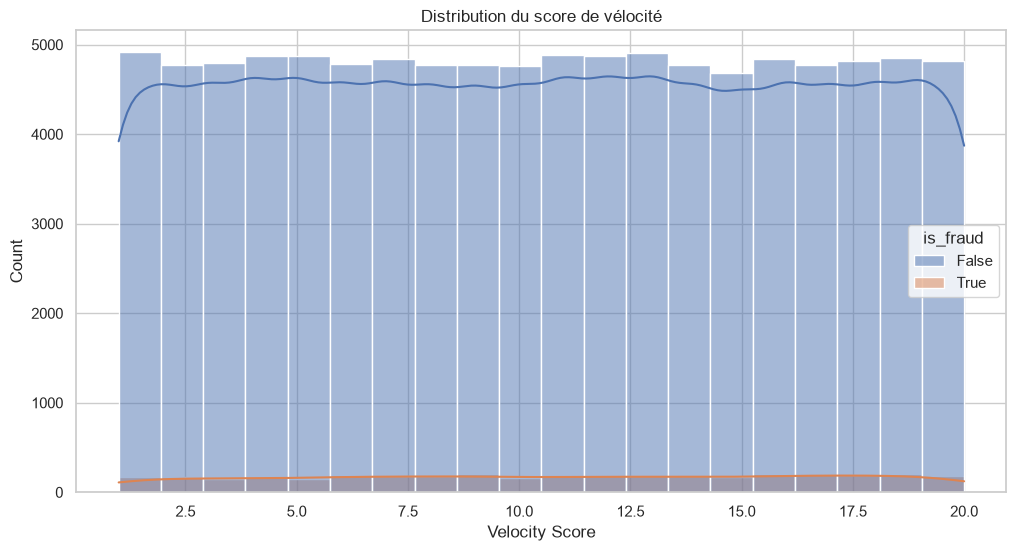

In [74]:
# Étape 3 : Histogramme -> Visualisation de la distribution du score de vélocité selon la fraude
sample = df.sample(100000, random_state=42)

plt.figure(figsize=(12,6))

sns.histplot(
    data=sample,
    x="velocity_score",
    hue="is_fraud",
    bins=20,
    kde=True
)

plt.title("Distribution du score de vélocité")
plt.xlabel("Velocity Score")

plt.savefig("../images/10_velocity_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

### Interprétation

Les statistiques descriptives montrent que le **score de vélocité** est quasiment identique pour les transactions frauduleuses et les transactions légitimes.

La moyenne est de **10,50** pour les transactions non frauduleuses contre **10,51** pour les transactions frauduleuses. De même, les médianes et les quartiles sont très proches, ce qui indique une distribution similaire entre les deux groupes.

Les boxplots confirment cette observation : les deux distributions se superposent presque entièrement et présentent une dispersion comparable. L'histogramme met également en évidence une répartition homogène des scores de vélocité, sans différence notable entre les transactions frauduleuses et les transactions légitimes.

Par conséquent, dans ce jeu de données, le **score de vélocité ne constitue pas un indicateur suffisamment discriminant** pour distinguer les transactions frauduleuses des transactions normales lorsqu'il est analysé isolément.

Cette observation suggère que la détection de fraude devra s'appuyer sur une combinaison de plusieurs variables plutôt que sur le seul score de vélocité.

### Conclusion

Les premières analyses montrent que les variables descriptives des transactions (montant, type de transaction, catégorie du commerçant et score de vélocité) présentent des distributions très similaires entre les transactions frauduleuses et les transactions légitimes. Ces variables, prises individuellement, ne permettent donc pas de discriminer efficacement les fraudes. Cette observation met en évidence la nécessité d'explorer d'autres variables ou de combiner plusieurs indicateurs afin d'améliorer la détection des comportements frauduleux.

## 5. Analyse des relations entre les variables numériques

### Question métier

Quelles variables numériques présentent la relation la plus forte avec la fraude ?

Cette analyse permet d'identifier les variables les plus susceptibles d'être utiles pour la détection des transactions frauduleuses.

In [75]:
# Étape 1 : Créer une version numérique de is_fraud
df_corr = df.copy()

df_corr["is_fraud"] = df_corr["is_fraud"].astype(int)

In [76]:
# Étape 2 : Garder uniquement les variables numériques
numeric_df = df_corr.select_dtypes(include=["number"])

In [77]:
# Étape 3 : Calcul de la matrice de corrélation

corr = numeric_df.corr()

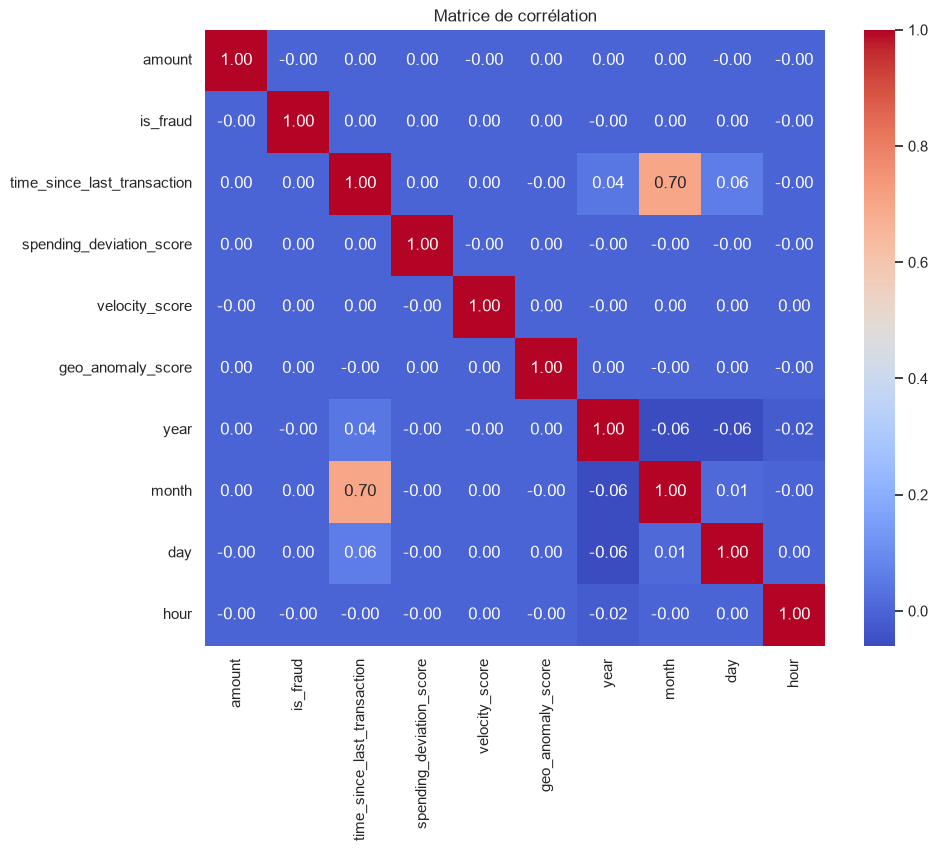

In [78]:
# Étape 4 : Visualisation de la matrice de corrélation -> Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")

plt.savefig("../images/correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### Interprétation

La matrice de corrélation met en évidence une **absence de corrélation linéaire significative** entre la variable cible `is_fraud` et les variables numériques du jeu de données.

Les coefficients de corrélation entre `is_fraud` et les variables telles que le montant (`amount`), le score de vélocité (`velocity_score`), le score d'anomalie géographique (`geo_anomaly_score`) ou encore le score de déviation des dépenses (`spending_deviation_score`) sont tous très proches de **0**.

Ces résultats indiquent qu'aucune de ces variables, prise individuellement, ne présente une relation linéaire suffisamment forte pour expliquer les transactions frauduleuses.

La seule corrélation notable observée concerne les variables **`month`** et **`time_since_last_transaction`** (≈ **0,70**). Cette relation est indépendante de la variable `is_fraud` et traduit probablement une caractéristique de construction du jeu de données plutôt qu'un indicateur de fraude.

Ainsi, cette analyse suggère que la détection des fraudes ne pourra probablement pas reposer sur une seule variable. Une approche combinant plusieurs caractéristiques ou l'utilisation de modèles de Machine Learning sera plus adaptée pour identifier les comportements frauduleux.

## 6. Analyse de la localisation

### Question métier

Certaines localisations présentent-elles un taux de fraude plus élevé que les autres ?

Cette analyse vise à identifier les zones géographiques pouvant nécessiter une surveillance renforcée.

In [79]:
# Étape 1 : Répartition des localisations

location_fraud_rate = (
    df.groupby("location")["is_fraud"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

location_fraud_rate

location
London       3.60
Toronto      3.60
New York     3.59
Berlin       3.59
Sydney       3.59
Singapore    3.59
Dubai        3.58
Tokyo        3.58
Name: is_fraud, dtype: float64

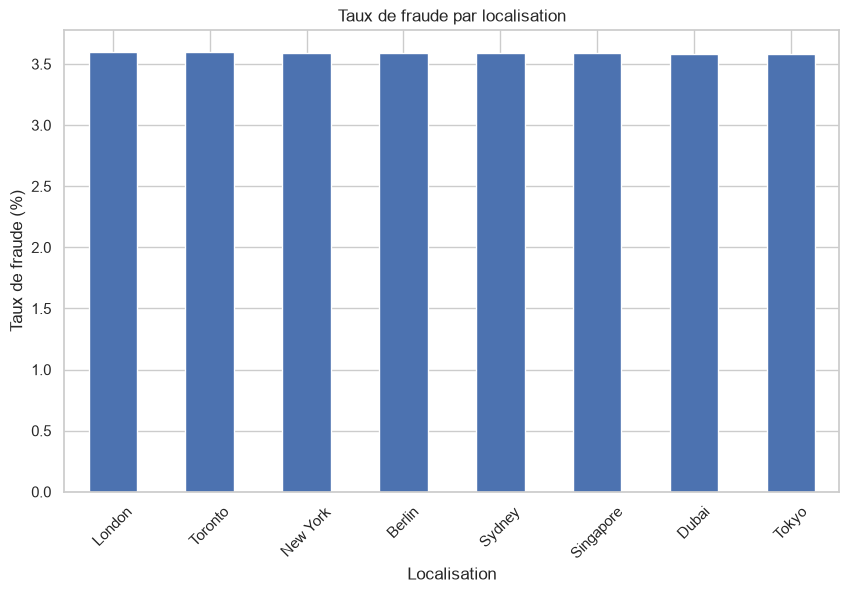

In [80]:
# Étape 2 : Diagramme en barres
plt.figure(figsize=(10,6))

location_fraud_rate.plot(kind="bar")

plt.title("Taux de fraude par localisation")
plt.xlabel("Localisation")
plt.ylabel("Taux de fraude (%)")

plt.xticks(rotation=45)

plt.savefig("../images/fraud_by_location.png", dpi=300, bbox_inches="tight")

plt.show()

### Interprétation

Les taux de fraude observés selon les différentes localisations sont très proches, compris entre **3,58 % et 3,60 %**.

Aucune ville ne présente un niveau de risque significativement supérieur aux autres. Les transactions effectuées à Londres, Toronto, New York, Berlin, Sydney, Singapour, Dubaï et Tokyo affichent des proportions de fraude quasiment identiques.

La localisation géographique ne semble donc pas constituer un facteur discriminant pour expliquer les transactions frauduleuses dans ce jeu de données.

## 7. Analyse du canal de paiement

### Question métier

Le canal de paiement influence-t-il le taux de fraude ?

L'objectif est d'identifier les moyens de paiement qui présentent un risque plus élevé.

In [81]:
# Étape 1 : Répartition des canaux de paiement
payment_fraud_rate = (
    df.groupby("payment_channel")["is_fraud"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

payment_fraud_rate

payment_channel
wire_transfer    3.60
UPI              3.59
card             3.59
ACH              3.58
Name: is_fraud, dtype: float64

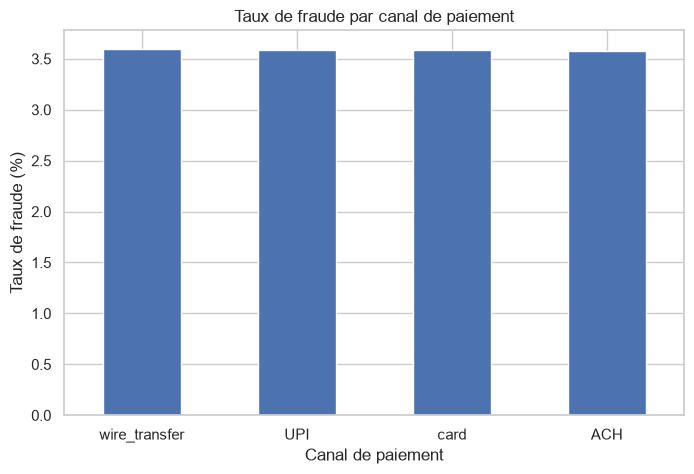

In [82]:
# Étape 2 : Diagramme en barres
plt.figure(figsize=(8,5))

payment_fraud_rate.plot(kind="bar")

plt.title("Taux de fraude par canal de paiement")
plt.xlabel("Canal de paiement")
plt.ylabel("Taux de fraude (%)")

plt.xticks(rotation=0)

plt.savefig("../images/fraud_by_payment_channel.png", dpi=300, bbox_inches="tight")

plt.show()

### Interprétation

Les différents canaux de paiement présentent des taux de fraude très similaires, compris entre **3,58 % et 3,60 %**.

Aucun canal de paiement ne ressort comme étant particulièrement exposé aux transactions frauduleuses. Les paiements par virement bancaire (*wire transfer*), carte bancaire, ACH et UPI présentent des niveaux de risque comparables.

Ainsi, le canal de paiement ne constitue pas, à lui seul, un indicateur pertinent pour distinguer les transactions frauduleuses des transactions légitimes.


## 8. Analyse de l'appareil utilisé

### Question métier

Le type d'appareil utilisé influence-t-il le risque de fraude ?

Cette analyse permet de déterminer si certaines plateformes de transaction sont plus exposées aux fraudes.

In [83]:
## Étape 1 : Répartition des appareils utilisés
device_fraud_rate = (
    df.groupby("device_used")["is_fraud"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

device_fraud_rate

device_used
atm       3.62
pos       3.59
web       3.58
mobile    3.57
Name: is_fraud, dtype: float64

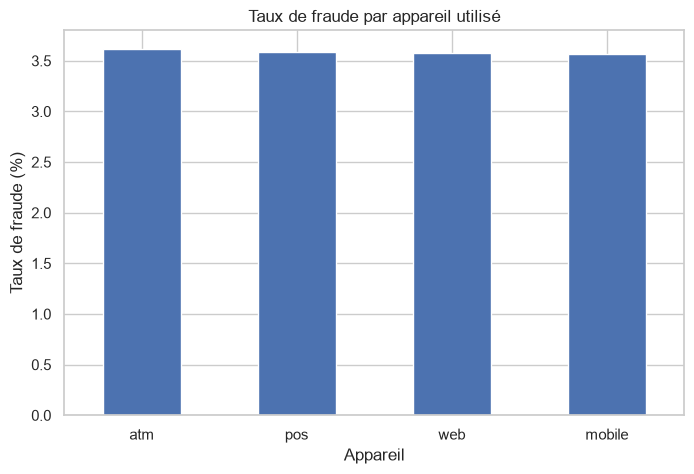

In [84]:
## Étape 2 : Diagramme en barres
plt.figure(figsize=(8,5))

device_fraud_rate.plot(kind="bar")

plt.title("Taux de fraude par appareil utilisé")
plt.xlabel("Appareil")
plt.ylabel("Taux de fraude (%)")

plt.xticks(rotation=0)

plt.savefig("../images/fraud_by_device.png", dpi=300, bbox_inches="tight")

plt.show()

### Interprétation

Les analyses montrent que le taux de fraude est très proche quel que soit l'appareil utilisé pour effectuer la transaction.

Les transactions réalisées via un distributeur automatique (ATM), un terminal de paiement (POS), le web ou un appareil mobile présentent toutes un taux de fraude voisin de **3,6 %**.

Ces résultats indiquent que le type d'appareil utilisé n'apporte pas d'information discriminante permettant d'identifier les transactions frauduleuses dans ce jeu de données.

# Conclusion générale

Cette analyse exploratoire avait pour objectif d'identifier les caractéristiques susceptibles de différencier les transactions frauduleuses des transactions légitimes.

Les analyses descriptives, les visualisations et l'étude des corrélations montrent que les principales variables étudiées (montant, type de transaction, catégorie de commerçant, localisation, canal de paiement, appareil utilisé et score de vélocité) présentent des distributions très similaires entre les deux classes de transactions.

Aucune variable analysée individuellement ne permet de distinguer clairement les transactions frauduleuses des transactions légitimes. Les coefficients de corrélation avec la variable cible `is_fraud` sont également très faibles, ce qui confirme l'absence de relation linéaire significative.

Ces résultats montrent que la détection de fraude ne peut probablement pas reposer sur une seule variable. Une approche plus avancée, reposant sur la combinaison de plusieurs caractéristiques ou sur l'utilisation d'algorithmes de Machine Learning, serait davantage adaptée pour identifier les comportements frauduleux.

Cette étude constitue ainsi une première étape essentielle permettant de mieux comprendre le jeu de données avant son intégration dans une architecture cloud et son exploitation au sein d'une application web.